> **Group:** Sara Martinez Rendon (1000424179) | Heider Zapata (1000009586) | Yeison Londoño (1000009479)  
> **Master's Degree in Data Sciences** | EAFIT University  
> **Course:** Applied Statistics   
> **Date:** 11/03/2026
---

# **Examen 1: Fundamentos de probabilidad**

---

## **Parte I: Diagnóstico de Cartera y Comportamiento del Cliente**

* **ID-Cliente:** Identificador único del solicitante (Alfanumérico).  
* **Ingreso-Mensual (X):** Ingreso neto reportado en miles de USD.  
* **Tipo-Vivienda (V):** Variable categórica con dos niveles: Propia o Alquilada.  
* **Mora-Previa (M):** Variable binaria que indica si el cliente ha tenido retrasos en pagos anteriores (1 = Sí, 0 = No).  
* **Estado-Credito (C):** Etiqueta de clasificación que representa el evento de interés.
   Puntaje:  
    - *C =1(Evento A):* El cliente incumplió con el pago (Default).  
    - *C =0(Evento Ac):* El cliente pagó exitosamente la totalidad del crédito.  

* **Psicometrico (S):** Un índice continuo (0 a 100) basado en un test de comportamiento frente al riesgo. Se busca modelar su función de densidad para entender la separación entre clientes aptos y no aptos.

In [36]:
#Cargar librerías y datos:

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats
from scipy.stats import gaussian_kde

#  Definimos la ruta para cargar los datos de manera externa sin depender de rutas locales
file_id = '1revJ7hH30v-Q-2-4sT7H7Q4V2mnQktkG'
url_datos = f'https://drive.google.com/uc?id={file_id}'

df = pd.read_csv(url_datos)

print("Dimensiones del df: ", df.shape)
df.head()

Dimensiones del df:  (10000, 6)


,ID_Cliente,Ingreso_Mensual,Tipo_Vivienda,Mora_Previa,Estado_Credito,Puntaje_Psicometrico
0,FT-00001,2.21,Propia,0,0,72
1,FT-00002,2.49,Alquilada,0,1,33
2,FT-00003,5.65,Propia,0,0,63
3,FT-00004,3.82,Alquilada,0,0,71
4,FT-00005,5.08,Alquilada,1,0,59


In [37]:
# chequeamos si hay valores nulos en los datos
df.isnull().sum()

ID_Cliente              0
Ingreso_Mensual         0
Tipo_Vivienda           0
Mora_Previa             0
Estado_Credito          0
Puntaje_Psicometrico    0
dtype: int64

### **Pregunta 1: Segmentación de Vivienda e Inestabilidad**

**1. ¿Qué tan representativo es el grupo de clientes que viven en arriendo pero que logran cumplir con sus obligaciones financieras respecto al total de la cartera?**

Primero se deben definir el conjunto y los subconjuntos que conforman el dataset como anteriormente se definió:

- **Ω** = 10.000 solicitantes para el crédito.
- **V** = {Cliente vive en vivienda Alquilada}
- **A** = {Cliente entra en Default} → `Estado_Credito = 1`
- **Aᶜ** = {Cliente paga exitosamente} → `Estado_Credito = 0`

Ahora para responder esta pregunta, en términos de conjuntos se ve como la intersección de ambos subconjuntos: $V \cap Aᶜ$

In [38]:
#Casos totales
n = len(df)

#Casos favorables: alquilan y pagan exitosamente
n_alq_paga   = len(df[(df['Tipo_Vivienda'] == 'Alquilada') & (df['Estado_Credito'] == 0)])

#Calculo de la probabilidad
p_alq_paga    = n_alq_paga   / n


print(f'Clientes que alquilan Y pagan exitosamente: {n_alq_paga}')
print(f'P(V ∩ Aᶜ) = {n_alq_paga} / {n} = {p_alq_paga:.4f}  ≈  {p_alq_paga*100:.2f}%')

Clientes que alquilan Y pagan exitosamente: 2913
P(V ∩ Aᶜ) = 2913 / 10000 = 0.2913  ≈  29.13%


**2. ¿Qué proporción de la base de datos total está compuesta por clientes que alquilan su vivienda y además presentan un estado de default?**

En términos de conjutos se ve como la intersección de dos subconjuntos: $V \cap A$

In [39]:
#Casos favorables: alquilan y no pagan exitosamente
n_alq_default = len(df[(df['Tipo_Vivienda'] == 'Alquilada') & (df['Estado_Credito'] == 1)])

#Calculo de la probabilidad
p_alq_default = n_alq_default / n

print(f'Clientes que alquilan Y están en default: {n_alq_default}')
print(f'P(V ∩ A) = {n_alq_default} / {n} = {p_alq_default:.4f}  ≈  {p_alq_default*100:.2f}%')

Clientes que alquilan Y están en default: 769
P(V ∩ A) = 769 / 10000 = 0.0769  ≈  7.69%


**Reflexión:**
 Si usted fuera el director de estrategia, ¿consideraría que el hecho de vivir en arriendo es un indicador suficiente para denegar un crédito de forma autom´atica? Utilice los valores obtenidos para sustentar su postura.

Para dar respuesta a esta pregunta, podemos comparar con las personas que tienen vivienda propia y de acuerdo a su estado de pagos exitosos o no (*default*).

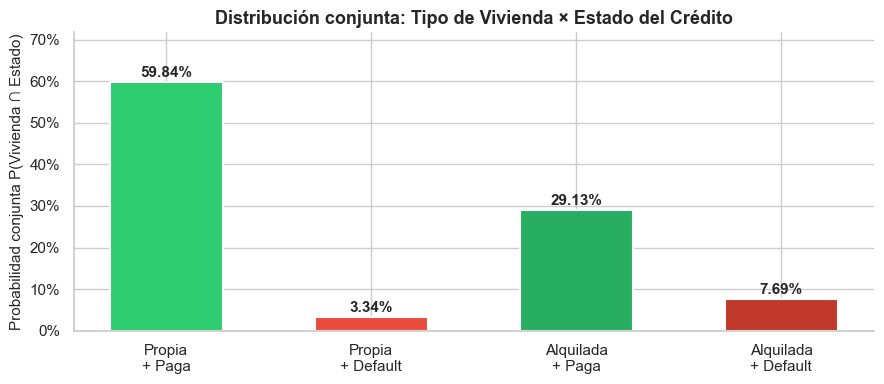

In [40]:
import matplotlib.patches as mpatches

categorias = ['Propia\n+ Paga', 'Propia\n+ Default', 'Alquilada\n+ Paga', 'Alquilada\n+ Default']
valores = [
    len(df[(df['Tipo_Vivienda']=='Propia')    & (df['Estado_Credito']==0)]) / n,
    len(df[(df['Tipo_Vivienda']=='Propia')    & (df['Estado_Credito']==1)]) / n,
    p_alq_paga,
    p_alq_default
]
colores = ['#2ecc71','#e74c3c','#27ae60','#c0392b']

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(categorias, valores, color=colores, edgecolor='white', linewidth=1.5, width=0.55)
for bar, val in zip(bars, valores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.2%}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_ylabel('Probabilidad conjunta P(Vivienda ∩ Estado)', fontsize=11)
ax.set_title('Distribución conjunta: Tipo de Vivienda × Estado del Crédito', fontsize=13, fontweight='bold')
ax.set_ylim(0, max(valores)*1.2)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

***¿Es vivir en arriendo un indicador suficiente para denegar crédito automáticamente?***

*No.* Los datos muestran que:

- El **29.13%** de toda la cartera son arrendatarios que **pagan exitosamente** → son clientes valiosos y fidelizables.
- Solo el **7.69%** son arrendatarios que incumplen (el *riesgo crítico* del área de cobranza).

Denegar crédito a todos los arrendatarios implicaría rechazar automáticamente casi el **37%** de la cartera total, de los cuales la gran mayoría (≈ 79%) son buenos pagadores. Una política tan rígida sería económicamente ineficiente y potencialmente discriminatoria. Lo correcto es usar el tipo de vivienda como **una variable más** en un modelo multivariado, no como criterio único de decisión.

### **Pregunta 2: El Peso del Pasado**

**1. Si seleccionamos al azar a un cliente que sabemos que tiene antecedentes de mora (Mora-Previa = 1), ¿cuál es la probabilidad de que este cliente termine efectivamente en default en su crédito actual?**


Esta pregunta se responde con una probabilidad condicional: 

$$P(A \mid M = 1) = \frac{P(A \cap M)}{P(M)}, \quad \text{con } P(M) > 0$$

In [41]:
# Probabilidad condicional: P(Default | Mora = 1) 
mora_si = df[df['Mora_Previa'] == 1]

# P(Default | Mora = 1)
p_def_dado_mora    = (mora_si['Estado_Credito'] == 1).sum() / len(mora_si)

print(f'Clientes con mora previa:          {len(mora_si)}')
print(f'De ellos, en default:              {(mora_si["Estado_Credito"]==1).sum()}')
print(f'P(Default | Mora=1) = {p_def_dado_mora:.4f}  →  {p_def_dado_mora*100:.2f}%')

Clientes con mora previa:          1198
De ellos, en default:              629
P(Default | Mora=1) = 0.5250  →  52.50%


**2. Compare este resultado con la probabilidad de default de un cliente del que no tenemos información previa de mora.**

Esta pregunta se responde con una probabilidad condicional: 

$$P(A \mid M = 0) = \frac{P(A \cap M)}{P(M)}, \quad \text{con } P(M) > 0$$


In [42]:
#Probabilidad condicional: P(Default | Mora = 0) 
mora_no = df[df['Mora_Previa'] == 0]

# P(Default | Mora = 0)
p_def_dado_no_mora = (mora_no['Estado_Credito'] == 1).sum() / len(mora_no)

print(f'Clientes SIN mora previa:          {len(mora_no)}')
print(f'De ellos, en default:              {(mora_no["Estado_Credito"]==1).sum()}')
print(f'P(Default | Mora=0) = {p_def_dado_no_mora:.4f}  →  {p_def_dado_no_mora*100:.2f}%')

Clientes SIN mora previa:          8802
De ellos, en default:              474
P(Default | Mora=0) = 0.0539  →  5.39%


**Reflexión:**
¿Es la Mora-Previa un predictor determinante o un distractor estadístico? ¿Cómo cambia su percepción del riesgo de un solicitante cuando este antecedente entra en la ecuación?

Para responder está pregunta debemos evaluar el riesgo que representa la mora previa o no, además de la probabilidad de que no se tengan pagos existosos (*default*) sin condiciones previas.

P(Default) marginal (sin condición) = 0.1103  →  11.03%

Factor de riesgo: tener mora previa multiplica el riesgo por 9.7x


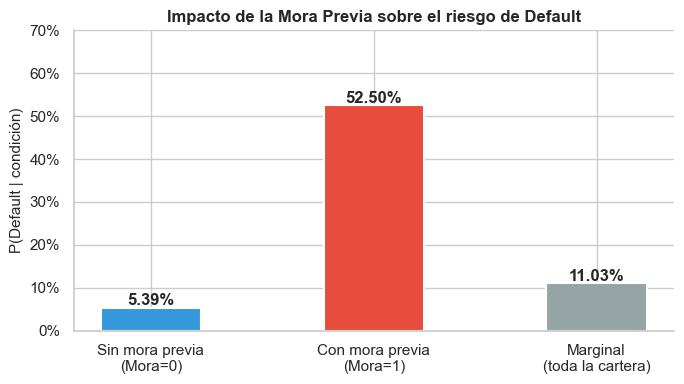

In [43]:
# P(Default) marginal
p_def_marginal     = (df['Estado_Credito'] == 1).sum() / n

print(f'P(Default) marginal (sin condición) = {p_def_marginal:.4f}  →  {p_def_marginal*100:.2f}%')
print(f'\nFactor de riesgo: tener mora previa multiplica el riesgo por {p_def_dado_mora/p_def_dado_no_mora:.1f}x')



# ── Visualización comparativa ──
fig, ax = plt.subplots(figsize=(7, 4))
grupos  = ['Sin mora previa\n(Mora=0)', 'Con mora previa\n(Mora=1)', 'Marginal\n(toda la cartera)']
probs   = [p_def_dado_no_mora, p_def_dado_mora, p_def_marginal]
colores = ['#3498db', '#e74c3c', '#95a5a6']

bars = ax.bar(grupos, probs, color=colores, width=0.45, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, probs):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f'{val:.2%}', ha='center', fontsize=12, fontweight='bold')

ax.set_ylabel('P(Default | condición)', fontsize=11)
ax.set_title('Impacto de la Mora Previa sobre el riesgo de Default', fontsize=12, fontweight='bold')
ax.set_ylim(0, 0.7)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

La mora previa es un **predictor muy determinante**, no un distractor. Pasar de no tener mora a tenerla **multiplica la probabilidad de default por casi 10x** (de 5.39% a 52.50%). 

Sin embargo, no es un predictor perfecto: el 47.5% de los clientes con mora previa *sí pagan* en esta ocasión. Esto sugiere que la mora previa debe elevar la señal de alerta y justificar condiciones más estrictas, como un menor monto, pero no necesariamente la denegación automática. En la práctica se combina con otras variables para un score más robusto.

### **Pregunta 3: El Dilema del Analista**

**¿Qué tan probable es que este cliente que nos acaba de incumplir ya hubiera tenido problemas de mora en el pasado?**

**Tarea:** Calcule la probabilidad de que un cliente tenga antecedentes de mora, dado que se encuentra en estado de default.
Utilice para ello los componentes del Teorema de Bayes derivados de la base de datos.

Basandonos en la condición calculada en la pregunta pasada, podemos aplicar Teorema de Bayes para calcular esa probabilidad.

El **Teorema de Bayes** permite invertir la dirección de la condicionalidad:

$$P(M=1 \mid A) = \frac{P(A \mid M=1) \cdot P(M=1)}{P(A)}$$

donde la probabilidad total del denominador se expande como:

$$P(A) = P(A \mid M=1) \cdot P(M=1) + P(A \mid M=0) \cdot P(M=0)$$

Identificamos:
- **Prior** → $P(M=1)$: probabilidad base de mora previa en la cartera
- **Verosimilitud** → $P(A \mid M=1)$: calculada en la Pregunta 2
- **Evidencia** → $P(A)$: probabilidad marginal de default
- **Posterior** → $P(M=1 \mid A)$: lo que queremos calcular

In [53]:
p_mora   = len(mora_si) / n                        # P(M=1) prior
p_no_mora = len(mora_no) / n                       # P(M=0)

# Verosimilitudes (calculadas en Pregunta 2)
# p_def_dado_mora     → P(A | M=1)
# p_def_dado_no_mora  → P(A | M=0)

# Probabilidad total de default (ley de probabilidad total)
p_def_total = p_def_dado_mora * p_mora + p_def_dado_no_mora * p_no_mora

# Posterior: P(M=1 | Default) — Bayes
p_mora_dado_def = (p_def_dado_mora * p_mora) / p_def_total

print('Componentes del Teorema de Bayes:')
print(f'  Prior         P(M=1)         = {p_mora:.4f}  ({p_mora*100:.2f}%)')
print(f'  Prior         P(M=0)         = {p_no_mora:.4f}  ({p_no_mora*100:.2f}%)')
print(f'  Verosimilitud P(A | M=1)     = {p_def_dado_mora:.4f}  ({p_def_dado_mora*100:.2f}%)')
print(f'  Verosimilitud P(A | M=0)     = {p_def_dado_no_mora:.4f}  ({p_def_dado_no_mora*100:.2f}%)')
print(f'  Evidencia     P(A)           = {p_def_total:.4f}  ({p_def_total*100:.2f}%)')
print()
print('Resultado:')
print(f'  Posterior  P(M=1 | Default)  = {p_mora_dado_def:.4f}  ({p_mora_dado_def*100:.2f}%)')

print()
print('Interpretación: De cada 100 clientes en default,',f'aproximadamente {p_mora_dado_def*100:.0f} ya tenían mora previa registrada.')


Componentes del Teorema de Bayes:
  Prior         P(M=1)         = 0.1198  (11.98%)
  Prior         P(M=0)         = 0.8802  (88.02%)
  Verosimilitud P(A | M=1)     = 0.5250  (52.50%)
  Verosimilitud P(A | M=0)     = 0.0539  (5.39%)
  Evidencia     P(A)           = 0.1103  (11.03%)

Resultado:
  Posterior  P(M=1 | Default)  = 0.5703  (57.03%)

Interpretación: De cada 100 clientes en default, aproximadamente 57 ya tenían mora previa registrada.


**Reflexión:**

Con **P(M=1 | Default) ≈ 57%**, más de la mitad de los clientes en default tenían mora previa. Esto **no significa causalidad directa**: el 43% restante son incumplimientos de clientes sin antecedentes, lo que evidencia que existen **factores externos** (pérdida de empleo, emergencias, ciclos económicos) que afectan incluso a clientes con historial impecable.

La mora previa es una señal fuerte pero no determinante. Un modelo de riesgo robusto debe complementarla con variables como el ingreso, el puntaje psicométrico y el tipo de vivienda.

---

## **Parte II: Análisis de Variables Aleatorias Continuas**

### **Pregunta 4: Modelado del Ingreso Mensual (X)**

**¿Los datos muestran una asimetría clara: hay muchos clientes con ingresos bajos y pocos con ingresos muy altos?**

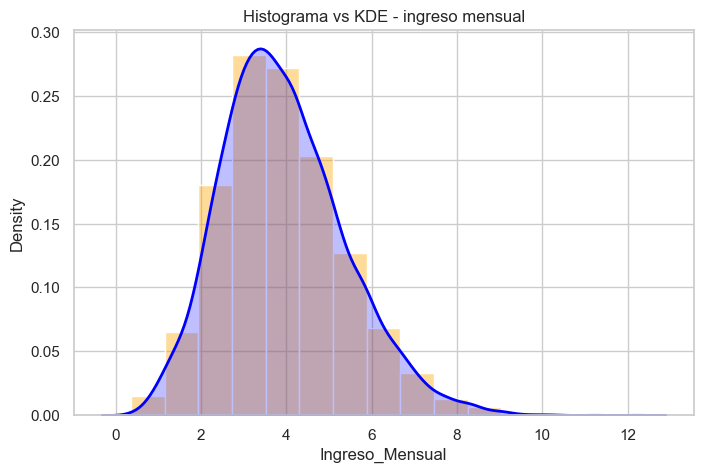

In [45]:
#ingreso_X = df["Ingreso_Mensual"].dropna()

ingreso_X = df["Ingreso_Mensual"]

plt.figure(figsize=(8, 5))
# Nota: stat="density" escala el histograma para que el área total sea 1 (probabilidad)
sns.histplot(data=ingreso_X, bins='sturges', color="orange", stat="density", alpha=0.4)
sns.kdeplot(data=ingreso_X, color="blue", bw_adjust=1.0, linewidth=2, fill=True)
plt.title("Histograma vs KDE - ingreso mensual")
plt.show()

Segun la gráfica y la distribución de los datos de ingresos mensuales, se observa una asimetría positiva (sesgo a la derecha) y se ve una **mayor concentración** de personas con ingresos medios y bajos entre $2$ mil y $5$ mil USD y se observa claramete que hay **pocas personas** con ingresos altos (superiores a $6$ mil USD). 

### **Pregunta 4.1**

Estime el valor esperado E[X] y la varianza Var(X) de los ingresos de la cartera total. 
¿Qué nos dice la diferencia entre la media y la mediana sobre la equidad de los ingresos en esta muestra?

In [46]:
# Estimación de la Esperanza Matemática (Media Muestral)
# Utilizamos numpy
esperanza_X = np.mean(ingreso_X)

# Estimación de la Varianza
# El parámetro ddof=1 asegura la corrección de grados de libertad (N-1)
varianza_X = np.var(ingreso_X, ddof=1)

# Cálculo de la Mediana (Percentil 50) para análisis de sesgo
mediana_X = np.median(ingreso_X)

# Impresión de resultados
print(f"Esperanza Matemática E[X] (Media): {esperanza_X:.2f} miles de USD")
print(f"Varianza Var(X): {varianza_X:.2f} (miles de USD)^2")
print(f"Mediana (Percentil 50): {mediana_X:.2f} miles de USD")

Esperanza Matemática E[X] (Media): 3.92 miles de USD
Varianza Var(X): 2.09 (miles de USD)^2
Mediana (Percentil 50): 3.77 miles de USD


Dado que E[X]=3.92 es mayor que la mediana de 3.77, estamos frente a una distribución con asimetría positiva (sesgada a la derecha). Matemáticamente, significa que el 50% de los clientes gana 3.77 o menos, pero existe una minoría de clientes (una "cola" en la distribución) con ingresos considerablemente altos que terminan arrastrando el promedio matemático hacia arriba. Por lo tanto, hay una ligera inequidad: el "cliente promedio" matemático gana más que la mayoría real de la población.

### **Pregunta 4.2**

Suponiendo que el ingreso sigue una distribución continua, aproxime la probabilidad de que un solicitante elegido al azar tenga un ingreso entre 3.0 y 5.0 mil USD

Respuesta: 
- Según la teoría de variables aleatorias continuas, la probabilidad de que una observación caiga en el intervalo [a,b] se define utilizando la Función de Distribución Acumulada (CDF) mediante la diferencia geométrica de sus límites: $$\mathbb{P}[a \le X \le b] = F_{X}(b) - F_{X}(a)$$

In [47]:
# Definición de los límites del intervalo
limite_inferior = 3.0
limite_superior = 5.0

# Filtro lógico (Máscara booleana)
# Evaluamos qué registros cumplen ambas condiciones simultáneamente
en_rango = (ingreso_X >= limite_inferior) & (ingreso_X <= limite_superior)

# Cálculo frecuentista de la probabilidad
# La media de un vector de booleanos (1s y 0s) equivale matemáticamente a la proporción de casos favorables
probabilidad_rango = np.mean(en_rango)

print(f"La probabilidad estimada P[3.0 <= X <= 5.0] es: {probabilidad_rango:.4f} (o {probabilidad_rango * 100:.2f}%)")

La probabilidad estimada P[3.0 <= X <= 5.0] es: 0.5108 (o 51.08%)


Obtener un 51.08% nos indica que **un poco más de la mitad de toda nuestra cartera de clientes se concentra en esa banda salarial estable de 3 a 5 mil USD**. Este resultado se evidencia en el gráfico de densidad expuesto en punto anterior donde vemos una alta concetración de clientes en estos rangos

### **Pregunta 4.3**

La empresa desea lanzar un producto “Premium” dirigido exclusivamente al 15 % de los clientes con mayores ingresos.
¿A partir de qué monto de ingreso mensual debería enviarse la invitación a este producto?

Respuesta: Si la empresa quiere invitar exclusivamente al 15% de los clientes con mayores ingresos, estadísticamente significa que debemos dejar por debajo al 85% restante. Para resolver esto, utilizamos los cuantiles (o percentiles), que nos permiten rebanar la distribución en cualquier punto exacto de la **Función de Distribución Acumulada (CDF)**

Buscamos el percentil 85. Matemáticamente, este es el valor más pequeño c tal que la probabilidad de que la variable aleatoria X sea menor o igual a c es exactamente 0.85: 
$$\mathbb{P}[X <= c] = Fx(c) = 0.85$$

Para hallar este valor en nuestro conjunto de datos, utilizaremos la estimación empírica de cuantiles mediante NumPy.

In [48]:
# Definimos el cuantil objetivo 
# Si queremos el 15% superior, buscamos el percentil 85 (0.85)
q = 0.85

# Estimación del cuantil empírico
# np.quantile ordena los datos bajo el capó y encuentra el valor de corte exacto
ingreso_premium = np.quantile(ingreso_X, q)

print(f"El umbral para enviar la invitación Premium (Percentil 85) es: {ingreso_premium:.2f} miles de USD")

El umbral para enviar la invitación Premium (Percentil 85) es: 5.41 miles de USD


**Reflexión: Si el valor esperado E[X] es significativamente mayor que el ingreso del 50 % de la población, ¿considera usted que la media es un indicador confiable para diseñar productos masivos, o debería la empresa basarse en los cuantiles para entender a su cliente promedio?**

**No se puede**. La Esperanza Matemática E[X] no es un indicador confiable en este escenario para diseñar productos masivos. Dado que la media es superior al ingreso de la mediana (el percentil 50), la variable presenta una clara asimetría positiva (sesgo a la derecha). Esto significa que la media está siendo arrastrada hacia arriba por una pequeña minoría de clientes con ingresos atípicamente altos.

Si la empresa diseña un producto masivo basándose en este valor esperado, paradójicamente estará fijando un umbral que excluye a la verdadera mayoría de su cartera. Por lo tanto, es estrictamente necesario basarse en los cuantiles (como la mediana), ya que son estimadores robustos frente a valores extremos. Los cuantiles dividen el área bajo la curva de probabilidad de manera equitativa, permitiendo entender con precisión la capacidad de pago real del cliente promedio. 

---

## **Parte III: Clasificación y Funciones de Densidad**

### **Pregunta 5: Análisis de Separabilidad mediante Puntaje Psicométrico (S)**

**Contexto:** La empresa ha implementado un test psicométrico que genera un puntaje $S ∈ [0, 100]$. Se cree que los clientes con mayor inteligencia financiera y estabilidad emocional obtienen puntajes más altos y, por ende, tienen menor probabilidad de default. El equipo de riesgos necesita definir un punto de corte: un valor de $S$ por debajo del cual el riesgo
sea inaceptable.

**Tarea:** Utilizando la variable Puntaje Psicometrico:


#### **5.1. Estime y grafique las funciones de densidad de probabilidad (PDF) del puntaje $S$ condicionadas al estado del crédito: $f(s|C = 0)$ y $f(s|C = 1)$.**

Utilizaremos la Estimación de Densidad por Kernel (KDE) para suavizar los histogramas y obtener una curva continua que represente la PDF. Superponer ambas curvas nos permitirá observar visualmente si el puntaje psicométrico es una buena variable para discriminar entre las dos clases de crédito. Si las curvas están muy separadas, la variable tiene buen poder predictivo; si se solapan casi por completo, la variable aporta poca información por sí sola.

In [49]:
#Verificamos que C toma los valores 0 y 1
lista_unicos = df['Estado_Credito'].unique().tolist()
print(lista_unicos)


[0, 1]


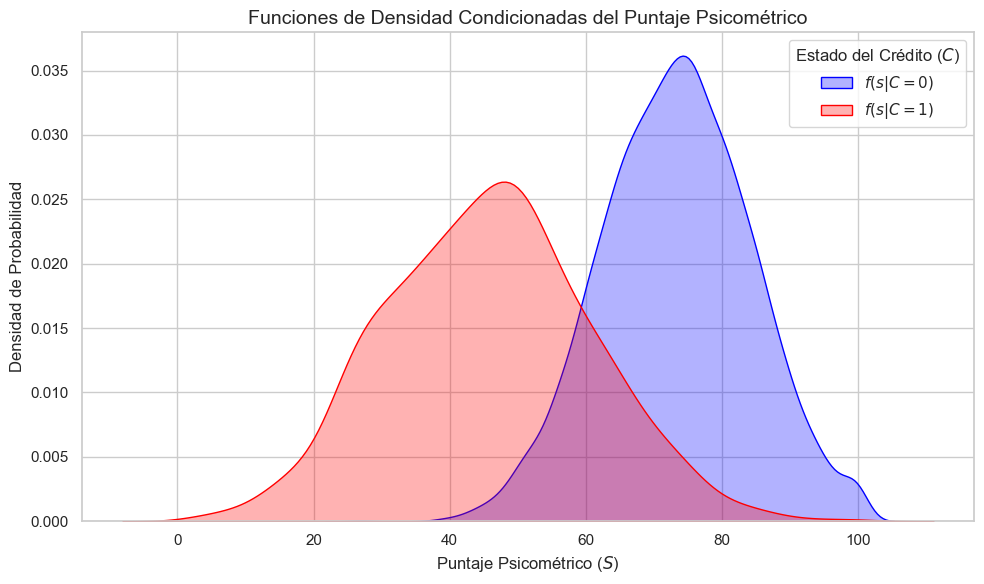

In [50]:
# Configuramos el estilo de las gráficas para que se vean más limpias
sns.set_theme(style="whitegrid")

#renombramos para mayor claridad
col_puntaje = 'Puntaje_Psicometrico' # Variable S
col_estado = 'Estado_Credito'        # Variable C

# Filtramos los datos por estado de crédito
puntaje_c0 = df[df[col_estado] == 0][col_puntaje]
puntaje_c1 = df[df[col_estado] == 1][col_puntaje]

# Creamos la figura
plt.figure(figsize=(10, 6))

# Estimamos y graficamos las PDFs usando KDE
sns.kdeplot(data=puntaje_c0, label='$f(s|C=0)$', fill=True, color='blue', alpha=0.3)
sns.kdeplot(data=puntaje_c1, label='$f(s|C=1)$', fill=True, color='red', alpha=0.3)

# Personalización del gráfico
plt.title('Funciones de Densidad Condicionadas del Puntaje Psicométrico', fontsize=14)
plt.xlabel('Puntaje Psicométrico ($S$)', fontsize=12)
plt.ylabel('Densidad de Probabilidad', fontsize=12)
plt.legend(title='Estado del Crédito ($C$)', fontsize=11)
    
# Mostrar el gráfico
plt.tight_layout()
plt.show()

Las distribuciones muestran una separación clara en sus medidas de tendencia central:

   * La clase $C=0$ (curva azul) tiende a concentrarse en puntajes psicometricos más altos, con su mayor densidad (moda) alrededor de $S = 75$.
   * Por el contrario, la clase $C=1$ (curva naranja) agrupa a clientes con puntajes psicometricos sistemáticamente más bajos, con un pico cercano a $S = 50$.
   * Esta separación indica que el puntaje psicométrico es una variable informativa (tiene buen poder predictivo) para ayudar a clasificar el estado del crédito.

No obstante, a pesar de la separación de las medias, existe una región de superposición significativa, aproximadamente entre los puntajes $S = 40$ y $S = 90$. En este intervalo, la probabilidad de pertenecer a cualquiera de las dos clases es considerable, lo que representa la zona de mayor incertidumbre para el modelo.

Este solapamiento hace que sea imposible trazar una línea vertical (un umbral duro) que separe perfectamente ambas clases sin cometer errores. Cualquier punto de corte que elijamos inevitablemente generará Falsos Positivos y Falsos Negativos. Esto confirma la necesidad de aplicar la **Teoría de la Decisión Bayesiana y la Matriz de Costos** (vista en clase) para encontrar el umbral óptimo que minimice el riesgo financiero esperado, en lugar de buscar una precisión absoluta que no existe en estos datos.

#### **5.2. Identifique visual o analíticamente el punto de intersección de ambas densidades. ¿Qué significado tiene este punto en términos de probabilidad de clasificacién errónea?**


Visualmente, el gráfico anterior indica que el punto de intersección de ambas densidades se encuentra un poco antes de $S=60$, veriquemos el punto exacto de intersección de manera analítica:

El punto exacto de intersección de las densidades es: S = 59.2543


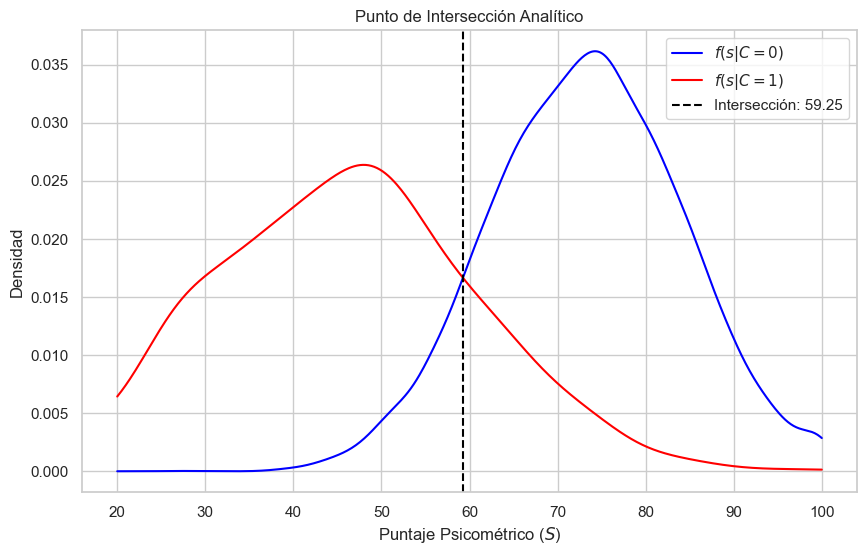

In [51]:
from scipy.stats import gaussian_kde
from scipy.optimize import fsolve

# 1. Reconstruimos las funciones de densidad (KDE) usando scipy para poder evaluarlas matemáticamente
kde_c0 = gaussian_kde(puntaje_c0)
kde_c1 = gaussian_kde(puntaje_c1)

# 2. Definimos una función que calcule la diferencia entre las dos densidades
def diferencia_kde(s):
    # Cuando esta función sea igual a 0, habremos encontrado la intersección
    return kde_c0(s) - kde_c1(s)

# 3. Buscamos el punto de intersección usando fsolve
# Le damos un valor inicial (x0=60) basado en nuestra inspección visual previa
punto_interseccion = fsolve(diferencia_kde, x0=60)[0]

print(f"El punto exacto de intersección de las densidades es: S = {punto_interseccion:.4f}")

# Opcional: Graficar el punto para confirmar
plt.figure(figsize=(10, 6))
s_rango = np.linspace(20, 100, 500)
plt.plot(s_rango, kde_c0(s_rango), label='$f(s|C=0)$', color='blue')
plt.plot(s_rango, kde_c1(s_rango), label='$f(s|C=1)$', color='red')
plt.axvline(punto_interseccion, color='black', linestyle='--', label=f'Intersección: {punto_interseccion:.2f}')
plt.title('Punto de Intersección Analítico')
plt.xlabel('Puntaje Psicométrico ($S$)')
plt.ylabel('Densidad')
plt.legend()
plt.show()

El cálculo analítico nos confirma que las funciones de densidad se cruzan exactamente en **S = 59.25**. En este punto, $f(s|C=0) = f(s|C=1)$. 

Si utilizamos este punto como frontera de decisión (aprobar a quienes estén por encima, rechazar a quienes estén por debajo) tendríamos dos tipos de errores representados por las áreas bajo las curvas que cruzan el umbral:

* **Falsos Negativos:** El área de la curva de malos clientes ($C=1$) que supera los 59.25 nos representa la probabilidad de aprobar a quien va a incumplir su obligación financiera.
* **Falsos Positivos:** El área de la curva de buenos clientes ($C=0$) que queda por debajo de 59.25 nos señala la probabilidad de rechazar a un cliente que cumpliría su obligación.

Al observar la **inclinación de las pendientes** justo en el punto de intersección, notamos una dinámica fundamental sobre cómo se comporta el riesgo:
1. La curva de los clientes que cumplen ($C=0$) tiene una pendiente marcadamente **positiva** y empinada. Esto significa que la concentración de buenos clientes crece muy rápido inmediatamente a la derecha de este umbral.
2. La curva de los clientes que incumplen ($C=1$) tiene una pendiente **negativa**, lo que indica que la densidad de malos clientes está disminuyendo hacia su cola derecha, aunque a un ritmo más lento.

En el escenario de este negocio particular, el costo de un Falso Negativo (perder el capital prestado) es mucho mayor que el de un Falso Positivo (el costo de oportunidad de perder un buen cliente). De esta manera, aunque las densidades se crucen en 59.25, no es recomendable tomar este punto como referencia para decidir, ya que matemáticamente asume que ambos errores cuestan lo mismo. 

Para minimizar la **Esperanza del error financiero**, el modelo debe aprovechar entonces esa fuerte pendiente positiva de la clase mayoritaria y protegerse del alto riesgo de default. Por lo tanto, el umbral óptimo de decisión tendrá que desplazarse hacia la derecha, exigiendo un puntaje en el test psicométrico más alto para aprobar el crédito.

#### **5.3. Calcule la probabilidad de que un cliente que efectivamente entró en default ($C = 1$) haya obtenido un puntaje "engañosamente alto” (mayor a $60$ puntos). Es decir, calcule $P(S > 60|C = 1)$.**

**Cálculo de Probabilidad Condicional: $P(S > 60 | C = 1)$**

Para calcular la probabilidad de que un cliente que entró en default ($C=1$) haya obtenido un puntaje mayor a $60$, necesitamos encontrar el área bajo la curva de su función de densidad de probabilidad desde $S=60$ hasta el infinito (o el valor máximo posible del puntaje).

Matemáticamente, esto se expresa mediante la siguiente integral definida:

$$P(S > 60 | C = 1) = \int_{60}^{\infty} f(s|C=1) ds$$

Dado que en el paso anterior estimamos $f(s|C=1)$ computacionalmente utilizando KDE (`gaussian_kde` de SciPy), podemos usar los métodos de integración numérica integrados en esta librería para calcular esta área de forma exacta sobre nuestra estimación empírica:

P(S > 60 | C = 1) = 17.64%


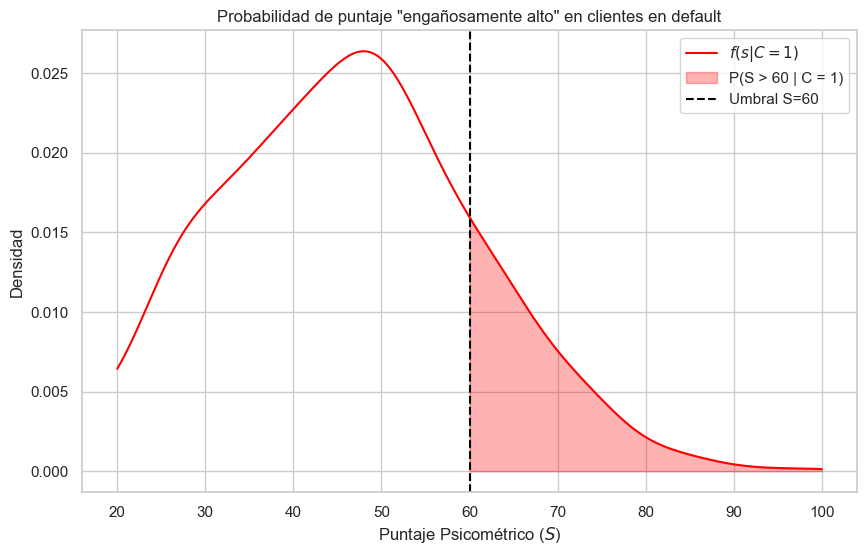

In [52]:
# Utilizamos el objeto kde_c1 que ya estimamos en el paso anterior
# El método integrate_box_1d calcula la integral de la densidad entre dos límites

limite_inferior = 60
limite_superior = np.inf # Integramos hasta el infinito (la cola derecha de la distribución)

# Cálculo de la probabilidad
prob_s_mayor_60_dado_c1 = kde_c1.integrate_box_1d(limite_inferior, limite_superior)

print(f"P(S > 60 | C = 1) = {prob_s_mayor_60_dado_c1 * 100:.2f}%")

# Visualización del área calculada;
plt.figure(figsize=(10, 6))
s_rango = np.linspace(20, 100, 500)

# Graficamos la PDF de C=1
plt.plot(s_rango, kde_c1(s_rango), color='red', label='$f(s|C=1)$')

# Sombreamos el área correspondiente a S > 60
s_sombreado = np.linspace(60, 100, 100)
plt.fill_between(s_sombreado, kde_c1(s_sombreado), color='red', alpha=0.3, label='P(S > 60 | C = 1)')

plt.axvline(60, color='black', linestyle='--', label='Umbral S=60')
plt.title('Probabilidad de puntaje "engañosamente alto" en clientes en default')
plt.xlabel('Puntaje Psicométrico ($S$)')
plt.ylabel('Densidad')
plt.legend()
plt.show()

**$P(S > 60 | C = 1)$ = 17.64%**

Esta proporción cuantifica el problema de solapamiento que identificamos visualmente en el primer punto (falsos positivos): el 17.64% de los clientes que efectivamente entraron en default (malos pagadores) lograron camuflarse en el test psicométrico, obteniendo un puntaje alto, superior a 60 puntos. 

Si el banco estableciera 60 como su "umbral duro" para aprobar créditos, casi 1 de cada 5 clientes riesgosos superaría el filtro. Esto se traduciría altos costos para la entidad financiera: desembolsos de capital que no serán recuperados.

Esto nos permite confirmar que la separación perfecta entre las clases es imposible usando solo esta variable. No deberíamos entonces buscar un punto de corte que elimine el error por completo, sino aplicar la matriz de costos para encontrar el umbral óptimo que, asumiendo este nivel de error inevitable, minimice la pérdida financiera esperada.

####  **5.4. Reflexión: Si las dos funciones de densidad se solapan significativamente (están muy juntas), ¿qué tan útil es el test psicométrico para predecir el default? ¿Preferiría usted un test donde las medias de las densidades estén más alejadas entre sí? Justifique.**

Si las dos funciones de densidad $f(s|C=0)$ y $f(s|C=1)$ se solaparan significativamente, la utilidad del test psicométrico para predecir el default sería **muy baja**. Al estar casi totalmente solapadas tendriamos que tanto los buenos pagadores como los que entran en default obtienen puntajes muy similares en el test psicométrico ($S$), así esta variable $S$ no estaría aportando información adicional suficiente para distinguir una clase de la otra.

Además, si intentaramos evaluar visualmente el área de incertidumbre a partir del punto de intercepción entre ambas funciones de densidad, tendriamos que, dado el alto solapamiento, mayor sería esta área de incertidumbre. Lo cual finalmente se traduciria en una alta tasa de Falsos Positivos y Falsos Negativos, sin importar cuánto optimicemos el umbral de decisión.

Dicho esto, sí es preferible un test donde las medias de las densidades estén más alejadas entre sí. Al estar las distribuciones más separadas, el área de traslape se encoge. Esto nos permite definir un umbral donde podemos aprobar a la gran mayoría de los buenos clientes (reduciendo la fricción y Falsos Positivos) y rechazar a casi todos los malos (evitando la pérdida de capital por Falsos Negativos). De esta manera, una separación amplia aleja al modelo de la zona de máxima incertidumbre y permite decisiones automatizadas mucho más seguras y rentables para el banco.

---